In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import datashader as ds
from datashader import transfer_functions as tf
from datashader.colors import Sets1to3  # Una paleta de colores predefinida
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import datashader as ds
import datashader.transfer_functions as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.cm import viridis
import PIL.Image as Image
import colorcet as cc
import matplotlib.colors as mcolors

In [41]:
df = pd.read_csv("/home/nicolas/nico/Data/Masivas/Data_OB_stars/Gaia_brighter_16.csv")

In [42]:
df["j_ks_0"] = df["j_m"] - df["ks_m"] - 0.25*(df["phot_g_mean_mag"]-df["ks_m"])


In [43]:
df["bp_rp"] = df["phot_bp_mean_mag"] - df["phot_rp_mean_mag"]
df["J-H"] = df["j_m"] - df["h_m"]

In [45]:
OBA_GDR3 =  df.loc[(df["phot_bp_mean_mag"].notna())&
          (df["phot_rp_mean_mag"].notna())&
      (df["phot_g_mean_mag"].notna())&
      (df["parallax"].notna())]

In [46]:
OBA_GDR3 = OBA_GDR3.loc[OBA_GDR3["parallax"] < 10**((10-OBA_GDR3["ks_m"])/5)]

In [47]:
OBA_GDR3["J-H"] = OBA_GDR3["j_m"] - OBA_GDR3["h_m"]

In [48]:
OBA_GDR3 = OBA_GDR3.loc[(OBA_GDR3["j_ks_0"]<0.1)&(OBA_GDR3["j_ks_0"]>-0.3)]
OBA_GDR3 = OBA_GDR3.loc[OBA_GDR3["J-H"]<0.15*(OBA_GDR3["phot_g_mean_mag"]-OBA_GDR3["ks_m"])+0.05]
OBA_GDR3 = OBA_GDR3.loc[OBA_GDR3["J-H"]>0.15*(OBA_GDR3["phot_g_mean_mag"]-OBA_GDR3["ks_m"])-0.15]
OBA_GDR3 = OBA_GDR3.loc[OBA_GDR3["phot_g_mean_mag"]> 2*(OBA_GDR3["phot_g_mean_mag"]-OBA_GDR3["ks_m"])+3]

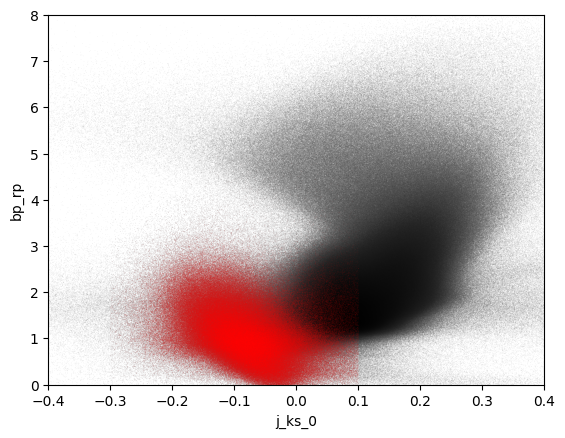

In [49]:
import pandas as pd
import datashader as ds
import datashader.transfer_functions as tf
import matplotlib.pyplot as plt

# Configurar los límites al crear el canvas
x_range = (-0.4, 0.4)
y_range = (0, 8)
canvas = ds.Canvas(plot_width=1000, plot_height=1000, x_range=x_range, y_range=y_range)

# Renderizar el scatter plot para el primer DataFrame
agg1 = canvas.points(df, 'j_ks_0', 'bp_rp')
img1 = tf.shade(agg1, cmap='black')

# Renderizar el scatter plot para el DataFrame OBA_GDR3
agg2 = canvas.points(OBA_GDR3, 'j_ks_0', 'bp_rp')
img2 = tf.shade(agg2, cmap='red')

# Combinar ambas imágenes
combined_img = tf.stack(img1, img2, how='over')

# Mostrar la imagen con ejes y mantener el aspecto de la imagen
plt.imshow(combined_img.to_pil(), extent=(x_range[0], x_range[1], y_range[0], y_range[1]), aspect='auto')
plt.xlabel('j_ks_0')
plt.ylabel('bp_rp')
plt.xlim(x_range)
plt.ylim(y_range)
plt.show()
